# Mars Rover Pathfinder — Autonomous Navigation using MDP

This notebook presents the design and implementation of an autonomous
navigation system for a Mars rover based on **Markov Decision Processes (MDP)**.

The objective is to enable a rover to navigate a Martian environment
under uncertainty, reach scientific sites, avoid hazards,
and minimize energy consumption.


## Problem Statement

Autonomous navigation on Mars faces several challenges:

- Uncertainty in rover motion due to wheel slippage and uneven terrain
- Presence of hazardous areas such as craters and dunes
- Strict energy constraints
- Limited or delayed human intervention

The goal of this project is to compute an **optimal navigation policy**
that maximizes the expected cumulative reward under uncertainty.


## Why Markov Decision Processes (MDP)?

The navigation problem is naturally modeled as a Markov Decision Process because:

- The rover state depends only on its current position
- Actions have probabilistic outcomes
- Mission objectives can be expressed through rewards
- Decisions must optimize long-term performance

An MDP is defined by the tuple:

**MDP = (S, A, P, R, γ)**


## MDP Formulation

- **S (States):** Rover positions (i, j) on a 2D grid
- **A (Actions):** {North, South, East, West}
- **P (Transitions):** Stochastic movement with lateral drift
- **R (Rewards):** Terrain-dependent rewards and penalties
- **γ (Discount Factor):** Controls the importance of future rewards


## Martian Environment (Grid World)

The Martian surface is represented as a 2D grid containing different terrain types:

- **Plain:** Normal terrain with low energy cost
- **Rock:** Impassable obstacle
- **Dune:** Difficult terrain with high energy cost
- **Crater:** Dangerous area
- **Scientific Site:** Terminal goal state

This modeling is inspired by real situations encountered in NASA Mars missions.


In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

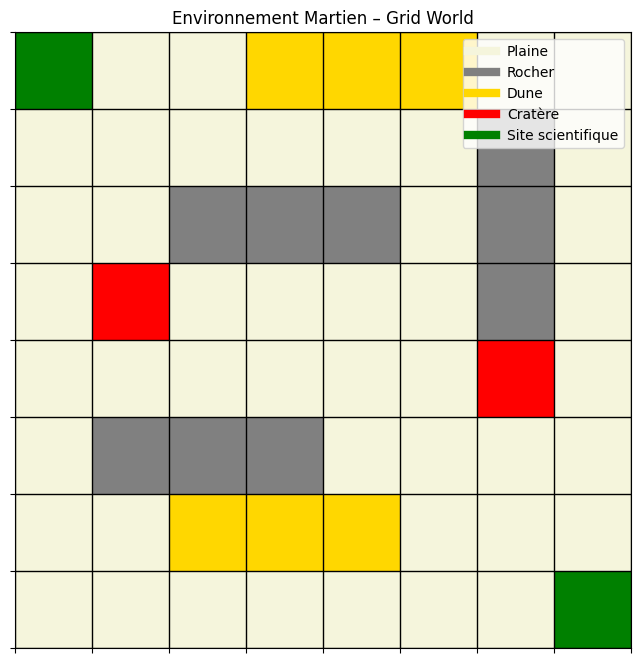

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors


class MarsGridWorld:
    """
    Grid-based representation of a Martian environment for autonomous rover navigation.
    This environment will later be modeled as a Markov Decision Process (MDP).
    """

    # Terrain identifiers (kept explicit for MDP clarity)
    PLAINE = 0
    ROCHER = 1
    DUNE = 2
    CRATERE = 3
    SITE_SCIENCE = 4

    def __init__(self, size=8):
        self.size = size
        self.grid = np.zeros((size, size), dtype=int)

        # Terrain semantics
        self.TERRAIN_TYPES = {
            self.PLAINE: 'plaine',          # Normal terrain
            self.ROCHER: 'rocher',          # Obstacle (impassable)
            self.DUNE: 'dune',              # High energy cost
            self.CRATERE: 'cratere',        # Dangerous zone
            self.SITE_SCIENCE: 'site_science'  # Terminal goal
        }

        # NASA mission analogs (contextual realism)
        self.NASA_ANALOGS = {
            self.PLAINE: "Jezero crater floor (Perseverance)",
            self.ROCHER: "Rock field hazard (Sol 180)",
            self.DUNE: "Hidden Valley sand trap (Spirit, 2009)",
            self.CRATERE: "Eagle Crater edge (Opportunity)",
            self.SITE_SCIENCE: "Delta front (primary science target)"
        }

        # Energy constraints (MMRTG-based)
        self.POWER_BUDGET_W = 110  # Watts
        self.DAILY_OPERATION_H = 6
        self.DAILY_ENERGY_J = self.POWER_BUDGET_W * self.DAILY_OPERATION_H * 3600

        self._setup_environment()

    def _setup_environment(self):
        """
        Configure the simulated Martian terrain.
        """
        # Default: plains
        self.grid[:, :] = self.PLAINE

        # Obstacles (rocks)
        self.grid[2, 2:5] = self.ROCHER
        self.grid[5, 1:4] = self.ROCHER
        self.grid[1:4, 6] = self.ROCHER

        # Dunes (high cost)
        self.grid[0, 3:6] = self.DUNE
        self.grid[6, 2:5] = self.DUNE

        # Craters (dangerous)
        self.grid[3, 1] = self.CRATERE
        self.grid[4, 6] = self.CRATERE

        # Scientific sites (terminal goals)
        self.grid[7, 7] = self.SITE_SCIENCE
        self.grid[0, 0] = self.SITE_SCIENCE





    def is_obstacle(self, terrain_type: int) -> bool:
        """
        Returns True if the terrain is impassable.
        """
        return terrain_type == self.ROCHER

    def is_terminal(self, terrain_type: int) -> bool:
        """
        Returns True if the terrain corresponds to a terminal (goal) state.
        """
        return terrain_type == self.SITE_SCIENCE

    def get_terrain_cost(self, terrain_type: int) -> float:
        """
        Energy cost in Joules per meter, inspired by NASA rover data.
        """
        energy_costs = {
            self.PLAINE: 50.0,     # Nominal traversal cost
            self.DUNE: 150.0,      # Wheel slip penalty
            self.CRATERE: 500.0    # Steep slope + hazard
        }
        return energy_costs.get(terrain_type, 0.0)

    # ---------- Visualization ----------

    def visualize_environment(self):
        """
        Visualize the Martian grid world.
        """
        fig, ax = plt.subplots(figsize=(8, 8))

        cmap = colors.ListedColormap(
            ['beige', 'gray', 'gold', 'red', 'green']
        )
        bounds = [0, 1, 2, 3, 4, 5]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        ax.imshow(self.grid, cmap=cmap, norm=norm)

        # Grid overlay
        ax.set_xticks(np.arange(-0.5, self.size, 1))
        ax.set_yticks(np.arange(-0.5, self.size, 1))
        ax.grid(color='black', linewidth=1)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # Legend
        labels = ['Plaine', 'Rocher', 'Dune', 'Cratère', 'Site scientifique']
        handles = [
            plt.Line2D([0], [0], color=cmap(i), lw=6)
            for i in range(len(labels))
        ]
        ax.legend(handles, labels, loc='upper right')

        ax.set_title("Environnement Martien – Grid World")
        plt.show()


# Notebook usage
mars_env = MarsGridWorld()
mars_env.visualize_environment()


## Reward Function Design

The reward function reflects mission priorities:

- **Scientific Site:** Large positive reward to encourage mission completion
- **Crater:** Strong negative reward to discourage dangerous paths
- **Rock:** Very high penalty to avoid collisions
- **Other terrains:** Negative reward proportional to energy consumption

This reward shaping promotes safe, efficient, and goal-oriented navigation.


## Stochastic Transition Model

Rover motion is uncertain due to mechanical and environmental factors:

- Intended action succeeds with high probability
- Lateral drift actions occur with non-zero probability

This stochastic model captures the uncertainty inherent in Martian navigation
and allows analysis of robustness under varying conditions.


In [ ]:
class MarsRoverMDP:
    """
    Markov Decision Process (MDP) for autonomous Mars rover navigation.
    """

    def __init__(self, environment,
                 gamma=0.9,
                 theta=1e-6,
                 p_intended=0.7,
                 p_drift=0.15):
        self.env = environment

        # MDP components
        self.actions = ['N', 'S', 'E', 'W']
        self.states = [
            (i, j)
            for i in range(environment.size)
            for j in range(environment.size)
        ]

        # Parameters
        self.gamma = gamma
        self.theta = theta

        # Transition probabilities (parameterized)
        self.p_intended = p_intended
        self.p_drift = p_drift

        # Value function and policy
        self.V = np.zeros((environment.size, environment.size))
        self.policy = np.empty((environment.size, environment.size), dtype=object)

        # Reward matrix
        self._setup_rewards()

    
    # Reward Function


    def _setup_rewards(self):
        """
        Reward design:
        - Scientific site: strong positive reward (goal)
        - Crater: strong negative reward (danger)
        - Obstacle: large penalty (discouraged, but unreachable anyway)
        - Other terrain: negative reward proportional to energy cost
        """
        self.rewards = np.zeros((self.env.size, self.env.size))

        for i in range(self.env.size):
            for j in range(self.env.size):
                terrain = self.env.grid[i, j]

                if self.env.is_terminal(terrain):
                    self.rewards[i, j] = 100.0
                elif self.env.is_obstacle(terrain):
                    self.rewards[i, j] = -100.0
                elif terrain == self.env.CRATERE:
                    self.rewards[i, j] = -50.0
                else:
                    # Movement cost derived from energy consumption
                    self.rewards[i, j] = -self.env.get_terrain_cost(terrain) / 10.0

    
    # Transition Model
 

    def transition_model(self, state, action):
        """
        Stochastic transition model reflecting Martian uncertainty.

        Returns:
            states: list of reachable next states
            probs: list of transition probabilities
        """
        possible_states = []
        probabilities = []

        # Intended movement
        next_state = self.get_next_state(state, action)
        possible_states.append(next_state)
        probabilities.append(self.p_intended)

        # Drift movements (sideways)
        for drift_action in self.get_drift_actions(action):
            drift_state = self.get_next_state(state, drift_action)
            possible_states.append(drift_state)
            probabilities.append(self.p_drift)

        return possible_states, probabilities

    
    # State Dynamics
    

    def get_next_state(self, state, action):
        """
        Computes the next state while respecting boundaries and obstacles.
        """
        i, j = state
        ni, nj = i, j

        if action == 'N':
            ni -= 1
        elif action == 'S':
            ni += 1
        elif action == 'E':
            nj += 1
        elif action == 'W':
            nj -= 1

        # Boundary check
        if not (0 <= ni < self.env.size and 0 <= nj < self.env.size):
            return state

        # Obstacle check
        if self.env.is_obstacle(self.env.grid[ni, nj]):
            return state

        return (ni, nj)

    def get_drift_actions(self, intended_action):
        """
        Returns lateral drift actions relative to intended movement.
        """
        if intended_action in ['N', 'S']:
            return ['E', 'W']
        return ['N', 'S']

    # Terminal State


    def is_terminal(self, state):
        """
        Checks if the given state is terminal.
        """
        i, j = state
        return self.env.is_terminal(self.env.grid[i, j])


## Solution Algorithm: Value Iteration

The MDP is solved using the **Value Iteration** algorithm,
which is based on the Bellman optimality equation:

V(s) = maxₐ Σₛ' P(s'|s,a) [ R(s,a,s') + γ V(s') ]

The algorithm iteratively updates the value function until convergence,
then extracts the optimal policy.


In [ ]:
class MarsValueIteration:
    """
    Value Iteration algorithm for solving the Mars Rover MDP.
    """

    def __init__(self, mdp):
        self.mdp = mdp
        self.V_history = []  # Track value function evolution

    # Value Iteration
   -

    def value_iteration(self):
        """
        Executes the Value Iteration algorithm until convergence.
        """
        iteration = 0

        while True:
            delta = 0.0
            new_V = np.copy(self.mdp.V)

            for state in self.mdp.states:
                i, j = state

                # Skip terminal and obstacle states
                if self.mdp.is_terminal(state):
                    continue
                if self.mdp.env.is_obstacle(self.mdp.env.grid[i, j]):
                    continue

                action_values = [
                    self.calculate_action_value(state, action)
                    for action in self.mdp.actions
                ]

                best_value = max(action_values)
                new_V[state] = best_value

                delta = max(delta, abs(best_value - self.mdp.V[state]))

            self.mdp.V = new_V
            self.V_history.append(np.copy(new_V))

            iteration += 1
            print(f"Iteration {iteration} | Δ = {delta:.6f}")

            # Convergence check
            if delta < self.mdp.theta:
                break

        # Extract optimal policy after convergence
        self.extract_policy()
        return iteration

    
    # Action-Value Computation
    

    def calculate_action_value(self, state, action):
        """
        Computes Q(s, a) using the Bellman expectation equation.
        """
        q_value = 0.0
        next_states, probs = self.mdp.transition_model(state, action)

        for next_state, prob in zip(next_states, probs):
            ni, nj = next_state
            q_value += prob * (self.mdp.rewards[ni, nj] + self.mdp.gamma * self.mdp.V[ni, nj])
        return q_value

    # Policy Extraction
    

    def extract_policy(self):
        """
        Extracts the optimal policy from the converged value function.
        """
        for i in range(self.mdp.env.size):
            for j in range(self.mdp.env.size):
                state = (i, j)

                if self.mdp.is_terminal(state):
                    self.mdp.policy[i, j] = 'GOAL'
                    continue
                if self.mdp.env.is_obstacle(self.mdp.env.grid[i, j]):
                    self.mdp.policy[i, j] = 'BLOCK'
                    continue

                best_action = None
                best_value = -np.inf

                for action in self.mdp.actions:
                    action_value = self.calculate_action_value(state, action)
                    if action_value > best_value:
                        best_value = action_value
                        best_action = action

                self.mdp.policy[i, j] = best_action

## Stochastic Policy Simulation

After computing the optimal policy, rover trajectories are simulated
by sampling transitions according to their probabilities.

Multiple trajectories may result from the same starting position,
illustrating the stochastic nature of the environment.


In [ ]:
import random
class MarsVisualizer:
    """
    Visualization and simulation utilities for the Mars Rover MDP.
    """

    def __init__(self, mdp, value_iteration):
        self.mdp = mdp
        self.vi = value_iteration

    
    # Value Function Convergence
    

    def plot_value_convergence(self):
        """
        Visualizes the convergence of the value function over iterations.
        """
        values_flat = [v.flatten() for v in self.vi.V_history]

        plt.figure(figsize=(12, 6))

        # Early iterations
        plt.subplot(1, 2, 1)
        for i in range(min(10, len(values_flat))):
            plt.plot(values_flat[i], alpha=0.7, label=f'Iter {i+1}')
        plt.xlabel('State index')
        plt.ylabel('Value')
        plt.title('Value Convergence (Early Iterations)')
        plt.legend()

        # Late iterations
        plt.subplot(1, 2, 2)
        for i in range(max(0, len(values_flat) - 10), len(values_flat)):
            plt.plot(values_flat[i], alpha=0.7, label=f'Iter {i+1}')
        plt.xlabel('State index')
        plt.ylabel('Value')
        plt.title('Value Convergence (Final Iterations)')
        plt.legend()

        plt.tight_layout()
        plt.show()


    # Policy Visualization
 

    def plot_optimal_policy(self):
        """
        Displays the optimal policy as arrows over the grid world.
        """
        fig, ax = plt.subplots(figsize=(10, 10))

        cmap = plt.cm.get_cmap('RdYlGn', 5)
        ax.imshow(self.mdp.env.grid, cmap=cmap, alpha=0.6)

        arrow_dict = {'N': '↑', 'S': '↓', 'E': '→', 'W': '←'}

        for i in range(self.mdp.env.size):
            for j in range(self.mdp.env.size):
                policy = self.mdp.policy[i, j]

                if policy in arrow_dict:
                    ax.text(j, i, arrow_dict[policy],
                            ha='center', va='center',
                            fontsize=16, fontweight='bold')
                elif policy == 'GOAL':
                    ax.text(j, i, '★',
                            ha='center', va='center',
                            fontsize=20, color='gold')
                elif policy == 'BLOCK':
                    ax.text(j, i, '✖',
                            ha='center', va='center',
                            fontsize=16, color='red')

        ax.set_xticks(np.arange(-0.5, self.mdp.env.size, 1))
        ax.set_yticks(np.arange(-0.5, self.mdp.env.size, 1))
        ax.grid(color='black', linewidth=2)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        ax.set_title('Politique Optimale du Rover Martien', fontsize=16)
        plt.show()

   
    # Stochastic Policy Simulation

    def simulate_optimal_path(self, start_position, max_steps=None):
        """
        Simulates a trajectory following the optimal policy
        using true stochastic transitions.
        """
        if max_steps is None:
            max_steps = self.mdp.env.size ** 2

        path = [start_position]
        current_pos = start_position

        for step in range(max_steps):
            if self.mdp.is_terminal(current_pos):
                print(f"Objectif atteint en {step} étapes.")
                break

            i, j = current_pos
            action = self.mdp.policy[i, j]

            if action not in self.mdp.actions:
                print(f"Arrêt à la position {current_pos} (état bloqué).")
                break

            next_states, probs = self.mdp.transition_model(current_pos, action)

            # TRUE stochastic simulation
            current_pos = random.choices(next_states, probs)[0]
            path.append(current_pos)

        return path

    # Path Visualization

    def plot_simulation_path(self, path):
        """
        Displays the simulated rover path on the grid.
        """
        fig, ax = plt.subplots(figsize=(10, 10))

        cmap = plt.cm.get_cmap('RdYlGn', 5)
        ax.imshow(self.mdp.env.grid, cmap=cmap, alpha=0.6)

        if len(path) > 1:
            y_coords = [pos[0] for pos in path]
            x_coords = [pos[1] for pos in path]

            ax.plot(x_coords, y_coords, 'b-', linewidth=3, alpha=0.7)
            ax.scatter(x_coords, y_coords,
                       c=range(len(path)),
                       cmap='viridis',
                       s=100, alpha=0.8)

            ax.scatter(x_coords[0], y_coords[0],
                       color='green', s=200,
                       marker='o', label='Départ')
            ax.scatter(x_coords[-1], y_coords[-1],
                       color='red', s=200,
                       marker='*', label='Arrivée')

        ax.legend()
        ax.set_title('Chemin Optimal Simulé du Rover', fontsize=16)
        plt.show()


## Convergence Criterion

Value Iteration converges when the maximum change in the value function
between two iterations falls below a predefined threshold θ.

The discount factor γ < 1 ensures convergence by making the Bellman operator
a contraction mapping.


In [27]:
import random

Initialisation de l'environnement martien...


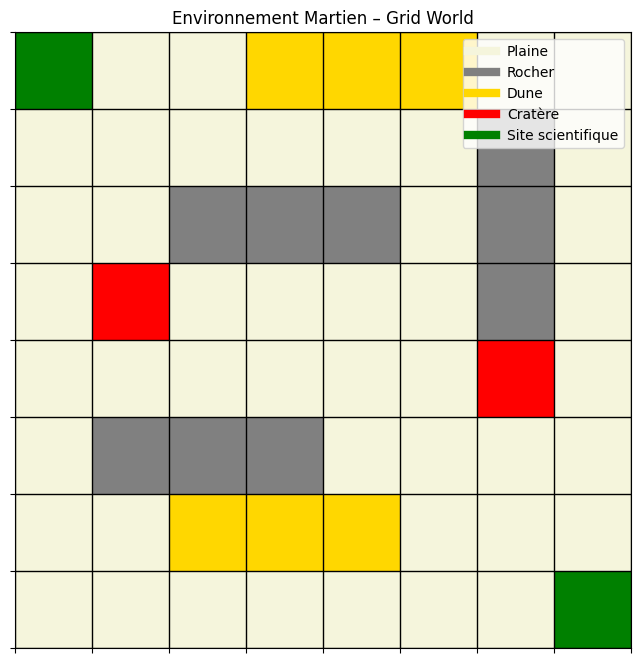

Configuration du MDP du rover...
Exécution de l'algorithme de Value Iteration...
Iteration 1 | Δ = 68.500000
Iteration 2 | Δ = 51.727500
Iteration 3 | Δ = 37.624500
Iteration 4 | Δ = 28.235992
Iteration 5 | Δ = 19.353266
Iteration 6 | Δ = 13.640714
Iteration 7 | Δ = 11.150515
Iteration 8 | Δ = 9.569047
Iteration 9 | Δ = 8.053625
Iteration 10 | Δ = 6.226648
Iteration 11 | Δ = 4.349891
Iteration 12 | Δ = 3.557114
Iteration 13 | Δ = 2.335121
Iteration 14 | Δ = 1.754492
Iteration 15 | Δ = 1.226411
Iteration 16 | Δ = 0.831561
Iteration 17 | Δ = 0.542892
Iteration 18 | Δ = 0.349589
Iteration 19 | Δ = 0.220104
Iteration 20 | Δ = 0.137851
Iteration 21 | Δ = 0.085113
Iteration 22 | Δ = 0.052521
Iteration 23 | Δ = 0.032104
Iteration 24 | Δ = 0.020241
Iteration 25 | Δ = 0.011968
Iteration 26 | Δ = 0.007941
Iteration 27 | Δ = 0.004444
Iteration 28 | Δ = 0.003098
Iteration 29 | Δ = 0.001661
Iteration 30 | Δ = 0.001204
Iteration 31 | Δ = 0.000657
Iteration 32 | Δ = 0.000467
Iteration 33 | Δ = 0.0002

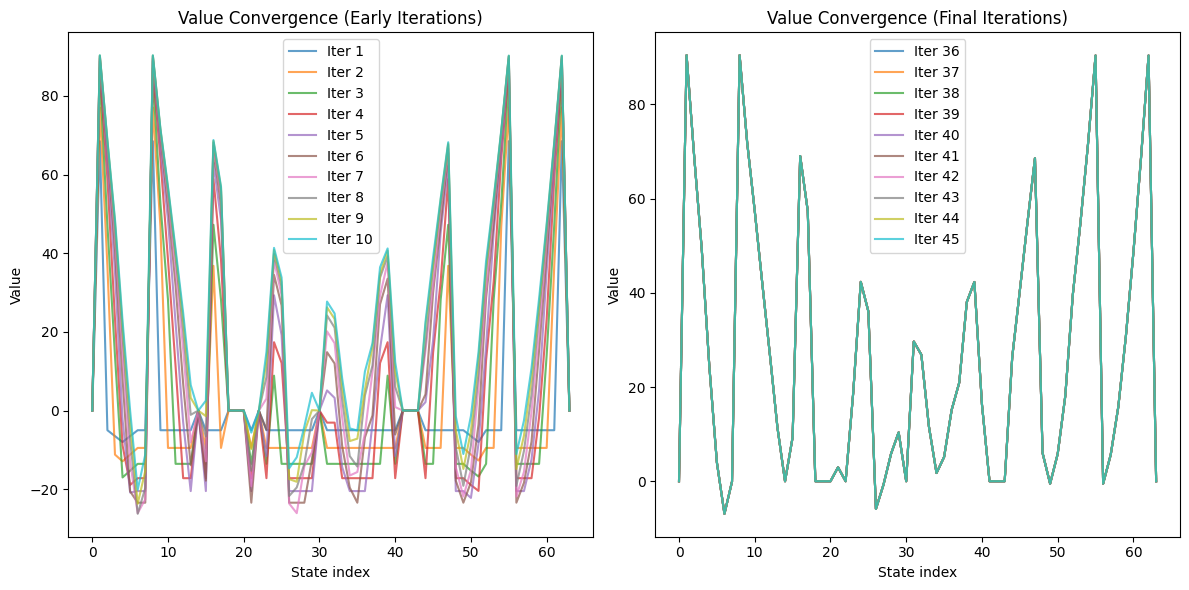

/tmp/ipython-input-459051652.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', 5)


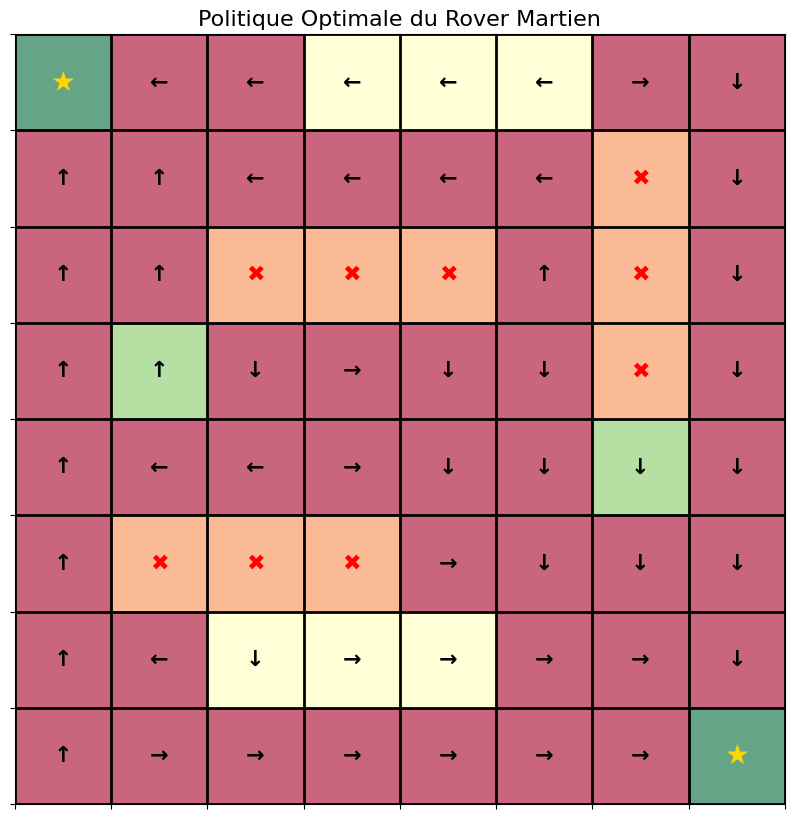

Simulation de trajectoires optimales (stochastiques)...

--- Simulation depuis la position initiale (0, 1) ---
Objectif atteint en 1 étapes.
Chemin suivi : [(0, 1), (0, 0)]


/tmp/ipython-input-459051652.py:129: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', 5)


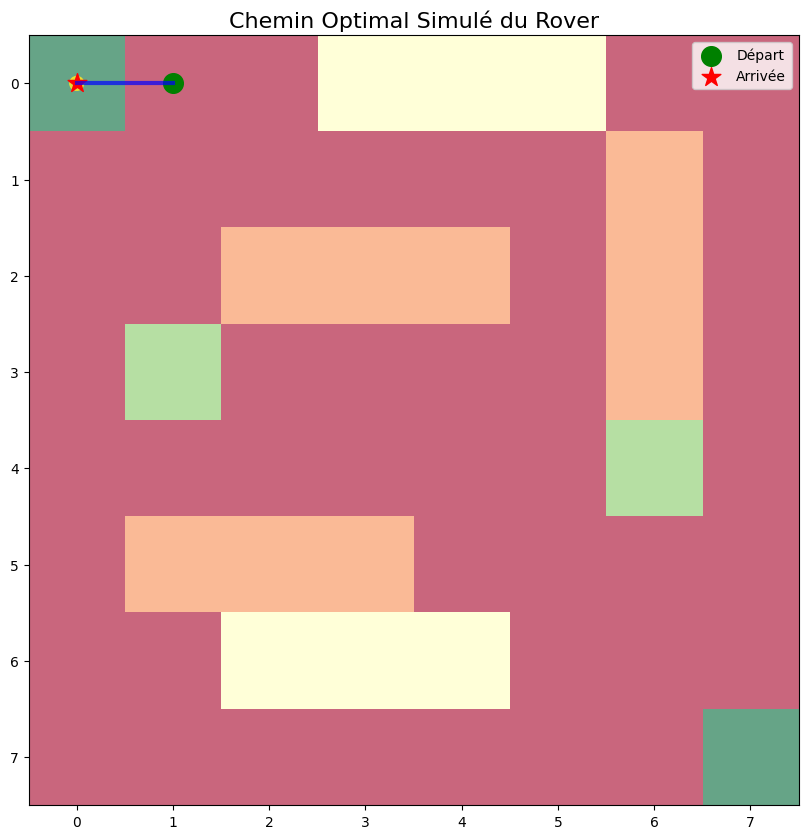


--- Simulation depuis la position initiale (3, 3) ---
Objectif atteint en 11 étapes.
Chemin suivi : [(3, 3), (3, 4), (4, 4), (4, 3), (4, 4), (5, 4), (5, 5), (5, 6), (6, 6), (6, 7), (6, 7), (7, 7)]


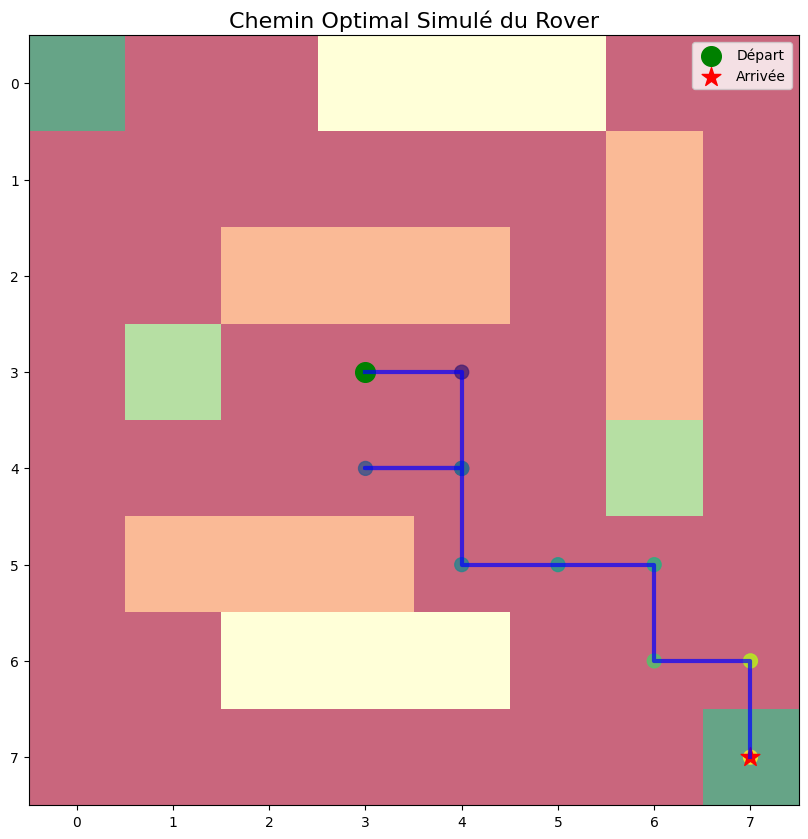


--- Simulation depuis la position initiale (6, 0) ---
Objectif atteint en 6 étapes.
Chemin suivi : [(6, 0), (5, 0), (4, 0), (3, 0), (2, 0), (1, 0), (0, 0)]


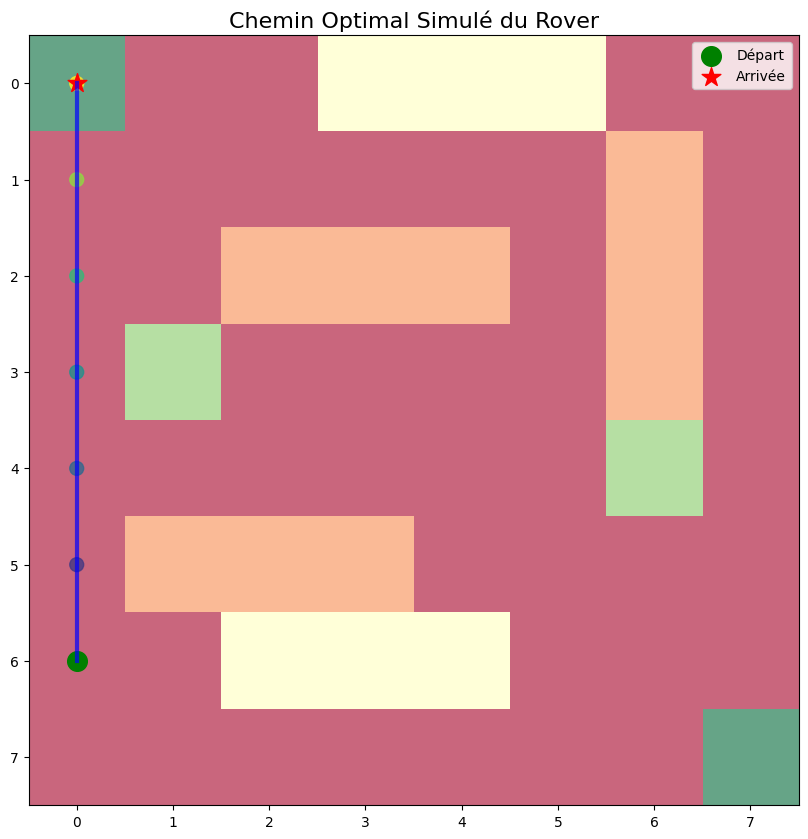


Analyse de la fonction de valeur optimale :
Valeur maximale : 90.41
Valeur minimale : -6.91


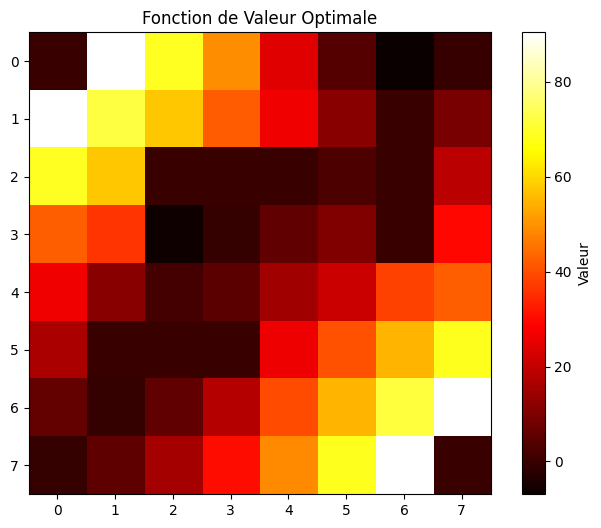

In [ ]:
# Pipeline principal – Mars Rover MDP


print("Initialisation de l'environnement martien...")

# 1. Création de l'environnement
mars_env = MarsGridWorld(size=8)
mars_env.visualize_environment()

# 2. Initialisation du MDP

print("Configuration du MDP du rover...")

rover_mdp = MarsRoverMDP(
    environment=mars_env,
    gamma=0.9,
    theta=1e-6,
    p_intended=0.7,
    p_drift=0.15
)

# 3. Résolution par Value Iteration

print("Exécution de l'algorithme de Value Iteration...")

vi_solver = MarsValueIteration(rover_mdp)
iterations = vi_solver.value_iteration()

print(f"Convergence atteinte après {iterations} itérations.")


# 4. Visualisation des résultats

print("Génération des visualisations...")

visualizer = MarsVisualizer(rover_mdp, vi_solver)

# Convergence de la fonction de valeur
visualizer.plot_value_convergence()

# Politique optimale
visualizer.plot_optimal_policy()

# 5. Simulation de trajectoires stochastiques

print("Simulation de trajectoires optimales (stochastiques)...")

start_positions = [(0, 1), (3, 3), (6, 0)]

for start_pos in start_positions:
    print(f"\n--- Simulation depuis la position initiale {start_pos} ---")
    path = visualizer.simulate_optimal_path(start_pos)
    print(f"Chemin suivi : {path}")
    visualizer.plot_simulation_path(path)


# 6. Analyse finale des résultats


print("\nAnalyse de la fonction de valeur optimale :")
print(f"Valeur maximale : {np.max(rover_mdp.V):.2f}")
print(f"Valeur minimale : {np.min(rover_mdp.V):.2f}")

plt.figure(figsize=(8, 6))
plt.imshow(rover_mdp.V, cmap='hot', interpolation='nearest')
plt.colorbar(label='Valeur')
plt.title('Fonction de Valeur Optimale')
plt.show()


## Visualization of Results

The following visualizations are provided:

- Value function convergence over iterations
- Optimal policy displayed as directional arrows
- 2D heatmap of the value function
- 3D surface of the optimal value function
- Simulated Martian topography
- Multiple stochastic rover trajectories in 3D

These visual tools facilitate interpretation and analysis.


In [37]:
import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



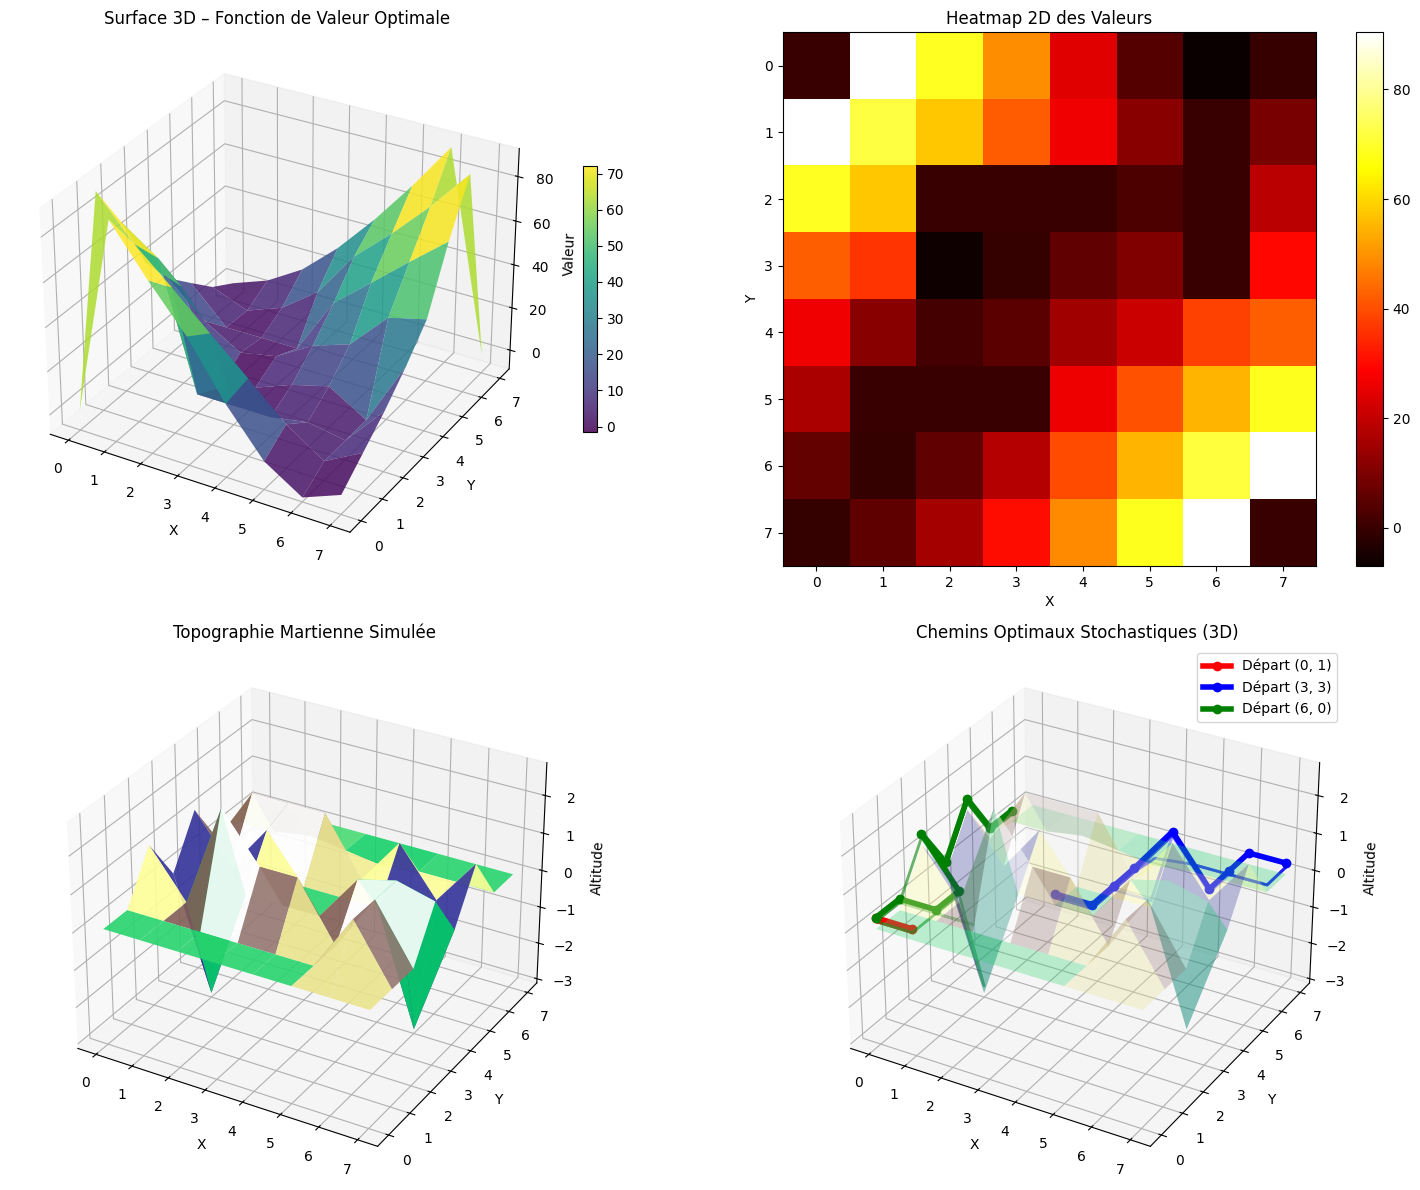

In [ ]:
class Mars3DVisualizer:
    """
    Visualisation 3D (Matplotlib) de la fonction de valeur
    et simulation de trajectoires stochastiques du rover martien.
    """

    def __init__(self, mdp, environment, value_iteration):
        self.mdp = mdp
        self.env = environment
        self.vi = value_iteration

    # Topographie martienne simulée

    def simulate_mars_topography(self):
        topo = np.zeros((self.env.size, self.env.size))

        for i in range(self.env.size):
            for j in range(self.env.size):
                terrain = self.env.grid[i, j]

                if terrain == self.env.CRATERE:
                    # Cratère (forme de bol)
                    for di in [-1, 0, 1]:
                        for dj in [-1, 0, 1]:
                            ni, nj = i + di, j + dj
                            if 0 <= ni < self.env.size and 0 <= nj < self.env.size:
                                d = np.sqrt(di**2 + dj**2)
                                topo[ni, nj] -= (1 - d) * 3

                elif terrain == self.env.DUNE:
                    topo[i, j] += np.sin(i * 0.5) * np.cos(j * 0.5) * 2

                elif terrain == self.env.ROCHER:
                    topo[i, j] += 1.5

        return topo

    # Simulation stochastique d’un chemin

    def simulate_path(self, start_position, max_steps=None, seed=None):
        """
        Simule un chemin en suivant la politique optimale
        avec une dynamique probabiliste P(s'|s,a).
        """
        if seed is not None:
            random.seed(seed)

        if max_steps is None:
            max_steps = self.env.size ** 2

        i0, j0 = start_position
        if not (0 <= i0 < self.env.size and 0 <= j0 < self.env.size):
            return []
        if self.env.is_obstacle(self.env.grid[i0, j0]):
            return []

        path = [start_position]
        current = start_position

        for _ in range(max_steps):
            if self.mdp.is_terminal(current):
                break

            i, j = current
            action = self.mdp.policy[i, j]

            if action not in self.mdp.actions:
                break

            next_states, probs = self.mdp.transition_model(current, action)
            probs = np.array(probs, dtype=float)
            probs /= probs.sum()

            current = random.choices(next_states, probs)[0]
            path.append(current)

        return path

    # Visualisation 3D complète

    def create_3d_surface(self, n_rollouts=5):
        """
        Affiche :
        - Surface 3D de la fonction de valeur
        - Heatmap 2D
        - Topographie martienne
        - Trajectoires stochastiques en 3D
        """
        X, Y = np.meshgrid(range(self.env.size), range(self.env.size))
        Z_val = self.mdp.V
        Z_topo = self.simulate_mars_topography()

        fig = plt.figure(figsize=(16, 12))

        # --- 1. Surface 3D des valeurs ---
        ax1 = fig.add_subplot(221, projection='3d')
        surf = ax1.plot_surface(X, Y, Z_val, cmap='viridis', alpha=0.85)
        ax1.set_title("Surface 3D – Fonction de Valeur Optimale")
        ax1.set_xlabel("X")
        ax1.set_ylabel("Y")
        ax1.set_zlabel("Valeur")
        fig.colorbar(surf, ax=ax1, shrink=0.5)

        # --- 2. Heatmap 2D ---
        ax2 = fig.add_subplot(222)
        im = ax2.imshow(Z_val, cmap='hot')
        ax2.set_title("Heatmap 2D des Valeurs")
        ax2.set_xlabel("X")
        ax2.set_ylabel("Y")
        fig.colorbar(im, ax=ax2)

        # --- 3. Topographie ---
        ax3 = fig.add_subplot(223, projection='3d')
        ax3.plot_surface(X, Y, Z_topo, cmap='terrain', alpha=0.9)
        ax3.set_title("Topographie Martienne Simulée")
        ax3.set_xlabel("X")
        ax3.set_ylabel("Y")
        ax3.set_zlabel("Altitude")

        # --- 4. Chemins stochastiques ---
        ax4 = fig.add_subplot(224, projection='3d')
        ax4.plot_surface(X, Y, Z_topo, cmap='terrain', alpha=0.3)

        start_positions = [(0, 1), (3, 3), (6, 0)]
        colors = ['red', 'blue', 'green']

        for idx, start in enumerate(start_positions):
            for _ in range(n_rollouts):
                path = self.simulate_path(start)
                if len(path) > 1:
                    xs = [p[1] for p in path]
                    ys = [p[0] for p in path]
                    zs = [Z_topo[p[0], p[1]] + 0.2 for p in path]
                    ax4.plot(xs, ys, zs,
                             color=colors[idx],
                             alpha=0.35,
                             linewidth=2)

            # Trajectoire représentative
            rep_path = self.simulate_path(start, seed=42)
            if len(rep_path) > 1:
                xs = [p[1] for p in rep_path]
                ys = [p[0] for p in rep_path]
                zs = [Z_topo[p[0], p[1]] + 0.3 for p in rep_path]
                ax4.plot(xs, ys, zs,
                         color=colors[idx],
                         linewidth=4,
                         marker='o',
                         label=f"Départ {start}")

        ax4.set_title("Chemins Optimaux Stochastiques (3D)")
        ax4.set_xlabel("X")
        ax4.set_ylabel("Y")
        ax4.set_zlabel("Altitude")
        ax4.legend()

        plt.tight_layout()
        plt.show()

visualizer_3d.create_3d_surface()



## Computational Complexity

Let:
- |S| be the number of states
- |A| be the number of actions

The computational complexity of Value Iteration is:

O(|S| × |A| × N)

where N is the number of iterations required for convergence.

For moderate grid sizes, this approach remains computationally tractable.


## Limitations and Future Work

Current limitations:
- Static environment
- Fixed grid resolution
- No online learning

Possible extensions:
- Reinforcement Learning (e.g., Q-learning)
- Dynamic or partially observable environments
- Moving obstacles
- Multi-objective optimization (energy, safety, time)


## Conclusion

This project demonstrates the effectiveness of Markov Decision Processes
for autonomous rover navigation in uncertain environments.

By combining a stochastic transition model, a carefully designed reward function,
and Value Iteration, a robust and interpretable navigation policy is obtained.

This work provides a solid foundation for further research and development
in autonomous robotic navigation and reinforcement learning.
